In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [12]:
import os
os.makedirs("../outputs", exist_ok=True)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

from src.data import load_spy_data
from src.features import create_features
from src.model import build_kmeans_matrix, assign_regime_labels

import config

2026-03-13 12:30:35.882 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-13 12:30:35.985 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-13 12:30:35.987 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Loading data from cache: C:\project_2\data\spy_data.csv
            Adj Close       Close        High         Low        Open  \
Date                                                                    
2005-03-15  81.497452  120.139999  121.459999  120.080002  121.419998   
2005-03-16  80.805511  119.120003  120.160004  118.900002  119.699997   
2005-03-17  80.968353  119.360001  119.739998  118.980003  119.309998   
2005-03-18  80.727913  118.540001  119.529999  118.150002  119.110001   
2005-03-21  80.428284  118.099998  118.779999  117.760002  118.709999   

              Volume  log_return  rolling_volatility  sma_ratio        rsi  
Date                                                                        
2005-03-15  62438500   -0.018065            0.007326   1.011440  44.620215  
2005-03-16  74874200   -0.015411            0.007489   1.010799  40.140175  
2005-03-17  62584200   -0.015628            0.007510   1.009935  41.625317  
2005-03-18  60232000   -0.015486            0.0

In [4]:
df = create_features(load_spy_data())

In [5]:
X = build_kmeans_matrix(df)

Scale Features

In [6]:
scaler = joblib.load(config.SCALER_FILE)
X_scaled = scaler.transform(X)

**Elbow Curve**

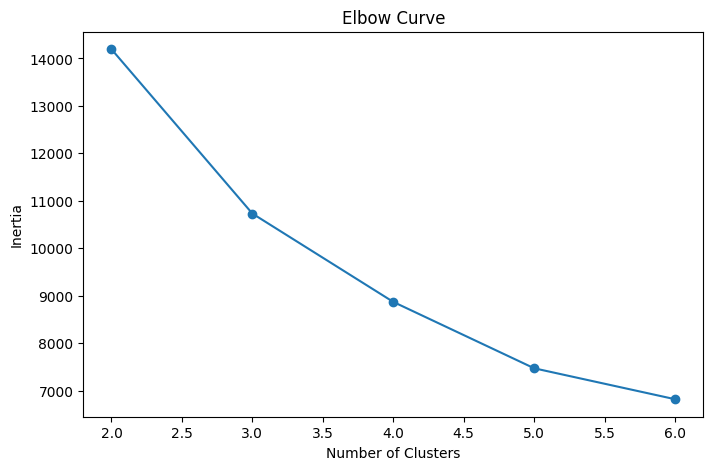

In [13]:
inertias = []

for k in range(2,7):

    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,7), inertias, marker='o')

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.savefig("../outputs/elbow_curve.png", dpi=300, bbox_inches="tight")

plt.show()



**Silhouette Scores**

In [16]:
sil_scores = []

for k in range(2,7):

    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

    print(f"k={k}  silhouette={score:.3f}")

k=2  silhouette=0.391
k=3  silhouette=0.372
k=4  silhouette=0.361
k=5  silhouette=0.311
k=6  silhouette=0.246


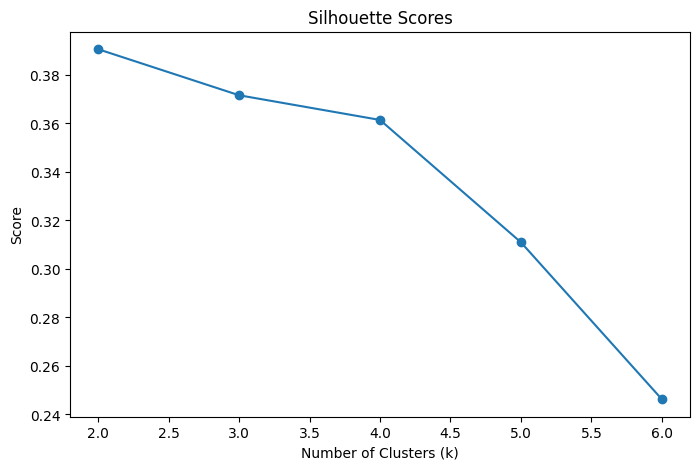

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(2,7), sil_scores, marker="o")

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")

plt.savefig("../outputs/silhouette_scores.png", dpi=300, bbox_inches="tight")

plt.show()

Load trained model

In [9]:
kmeans = joblib.load(config.KMEANS_MODEL_FILE)

Predict regimes

In [10]:
labels = kmeans.predict(X_scaled)

df_regime, regime_map = assign_regime_labels(df, labels)

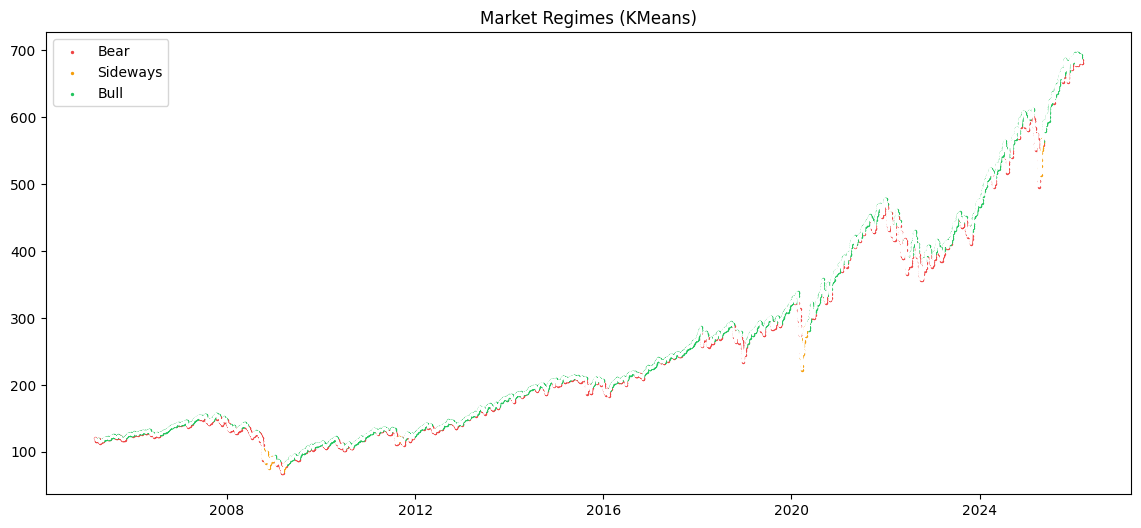

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df_regime.index, df_regime["Close"], color="white")

for regime, color in config.REGIME_COLORS.items():

    mask = df_regime["regime"] == regime

    plt.scatter(
        df_regime.index[mask],
        df_regime["Close"][mask],
        color=color,
        s=2,
        label=regime
    )

plt.title("Market Regimes (KMeans)")
plt.legend()

plt.savefig("../outputs/regime_map.png", dpi=300, bbox_inches="tight")

plt.show()